In [1]:
import os
if os.path.basename(os.getcwd()) == 'Demonstrations':
    os.chdir('..')

<div style="background-color: #cbcaf0; color: white; padding: 30px; border-radius: 0px;">
<h1 style="margin: 0;  color: #04335a">Stokes Equations on an Exchanger Device</h3>
</div>

Imports:

In [ ]:
import numpy as np
from scipy.sparse.linalg import spsolve

import matplotlib.pyplot as plt
import matplotlib.tri as tri

from Utilities.Stokes_felib import (
    calculate_velocity_A,
    calculate_pressure_B,
    calculate_Saddle_point_K
)

from Utilities.Mesh_processing import (
    refine
)

from Utilities.Plot_functions import (
    Plot_Initial_Refined_meshes,
    plot_streamlines,
    plot_pressure
)

---

Mesh:

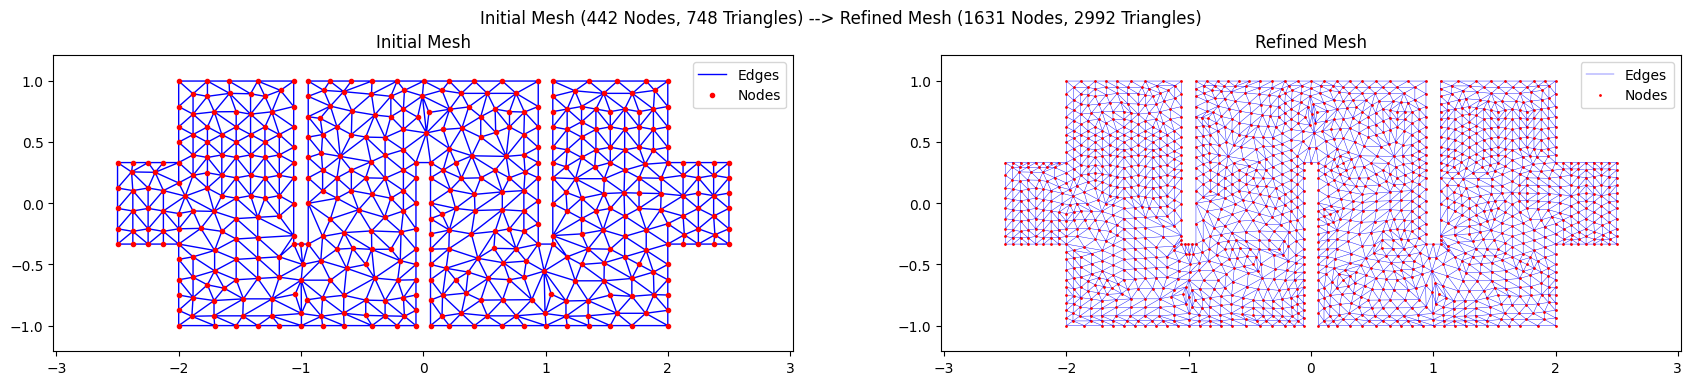

In [19]:
p_coarse, e_coarse, t_coarse = Plot_Initial_Refined_meshes(
    data_path='Meshes/exchanger_device_altered_mesh_data.npz',
    num_of_refinements=1,
    figsize=(21, 4),
    plot=True
)
p_fine, e_fine, t_fine = refine(p_coarse, e_coarse, t_coarse)

Inlet profile:

In [67]:
def parabolic_inlet_profile(x, x_1, x_2, alpha):
    return -alpha*(x - x_1)*(x - x_2)

Nv = p_fine.shape[0]
Np = p_coarse.shape[0]
eps = 1e-10   

xmin = p_fine[:, 0].min()
xmax = p_fine[:, 0].max()

inlet_idx  = np.where(np.abs(p_fine[:, 0] - xmin) < eps)[0]
outlet_idx = np.where(np.abs(p_fine[:, 0] - xmax) < eps)[0]

corner_idx  = [inlet_idx[np.argmax(p_fine[inlet_idx, 1])], 
               inlet_idx[np.argmin(p_fine[inlet_idx, 1])]]

boundary_nodes = np.unique(e_fine[e_fine[:, 2] > 0, 0:2])
v_wall_idx = np.setdiff1d(boundary_nodes, np.concatenate([inlet_idx, outlet_idx]))
dirichlet_nodes = np.unique(np.concatenate([inlet_idx, v_wall_idx]))

lf_x = np.zeros(Nv)
lf_y = np.zeros(Nv)

y_inlet = p_fine[inlet_idx, 1]
y_top, y_bottom = p_fine[corner_idx[0], 1], p_fine[corner_idx[1], 1]
lf_x[inlet_idx] = parabolic_inlet_profile(y_inlet, y_top, y_bottom, alpha=3)

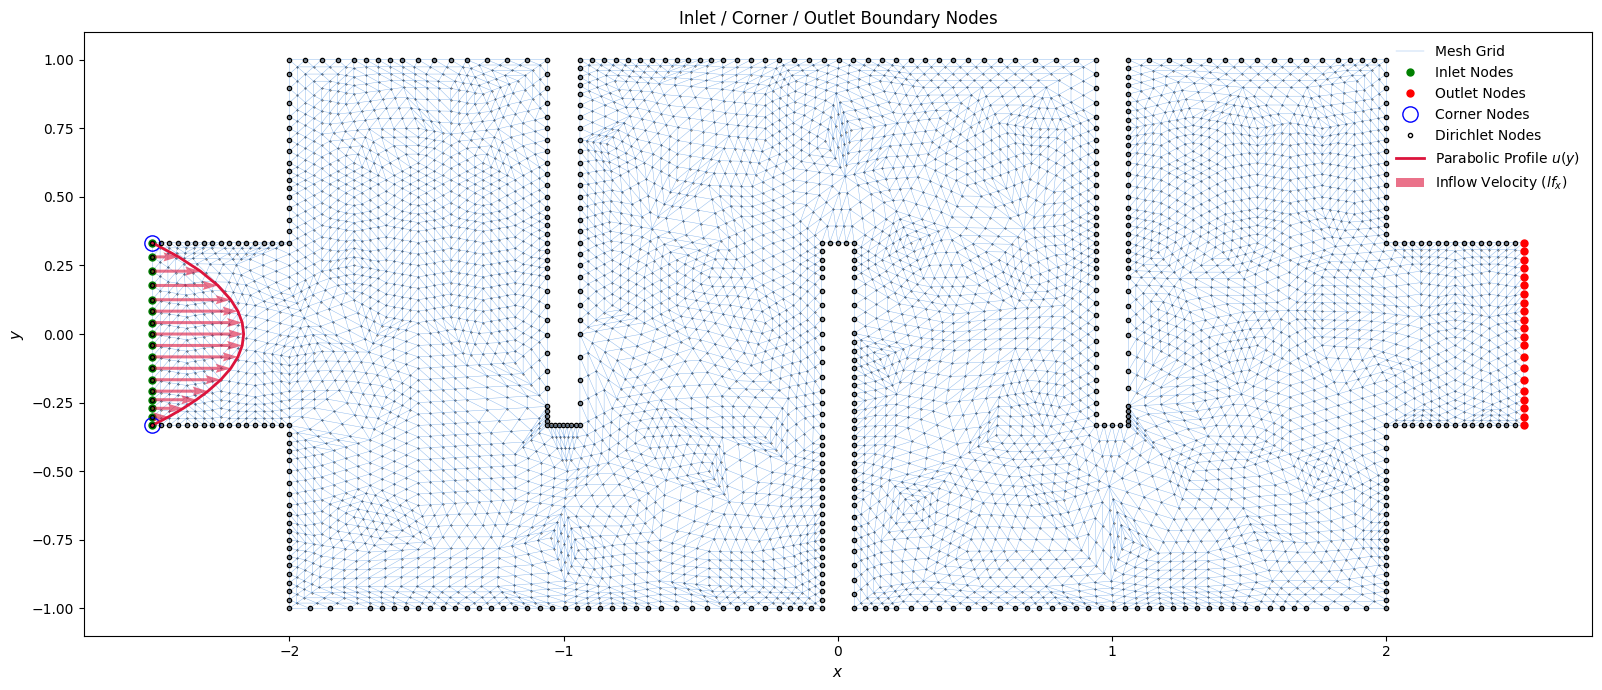

In [68]:
fig, ax = plt.subplots(figsize=(21, 7))

ax.triplot(p_fine[:, 0], p_fine[:, 1], t_fine[:, :3], color='#4A90E2', lw=0.3, alpha=0.7, label='Mesh Grid')
ax.plot(p_fine[:, 0], p_fine[:, 1], 'o', color='k', markersize=0.3, alpha=1)
ax.plot(p_fine[inlet_idx, 0],  p_fine[inlet_idx, 1],  'go', markersize=5, zorder=5, label='Inlet Nodes')
ax.plot(p_fine[outlet_idx, 0], p_fine[outlet_idx, 1], 'ro', markersize=5, zorder=5, label='Outlet Nodes')
ax.plot(p_fine[corner_idx, 0], p_fine[corner_idx, 1], 'bo', markersize=11, zorder=7, markerfacecolor='none', label='Corner Nodes')
ax.plot(p_fine[dirichlet_nodes, 0], p_fine[dirichlet_nodes, 1], 'ko', markersize=3, zorder=10, markerfacecolor='none', label='Dirichlet Nodes')

sort_perm = np.argsort(y_inlet)
ax.plot(xmin + lf_x[inlet_idx][sort_perm], y_inlet[sort_perm], color='crimson', lw=2, zorder=8, label='Parabolic Profile $u(y)$')
ax.quiver(p_fine[inlet_idx, 0], y_inlet, lf_x[inlet_idx], np.zeros_like(y_inlet), angles='xy', scale_units='xy', scale=1, color='crimson', alpha=0.6, width=0.002, zorder=6, label=r'Inflow Velocity ($lf_x$)')

ax.set_aspect('equal')
ax.set_xlabel('$x$', fontsize=11)
ax.set_ylabel('$y$', fontsize=11)
ax.set_title('Inlet / Corner / Outlet Boundary Nodes', fontsize=12)
ax.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')
ax.grid(False)

plt.tight_layout()
# plt.savefig("Outputs/Inlet_Boundary_Highlight.png", dpi=300)
plt.show()

In [ ]:
def compute_U_P_solution_exchanger_device(p_fine, t_fine, e_fine, p_coarse, t_coarse,
                                          inlet_velocity: float = 1.0,
                                          kinematic_viscosity: float = 1,
                                          return_matrices: bool = False):

    Nv = p_fine.shape[0]
    Np = p_coarse.shape[0]
    eps = 1e-10   

    xmin = p_fine[:, 0].min()
    xmax = p_fine[:, 0].max()

    inlet_idx  = np.where(np.abs(p_fine[:, 0] - xmin) < eps)[0]
    outlet_idx = np.where(np.abs(p_fine[:, 0] - xmax) < eps)[0]

    boundary_nodes = np.unique(e_fine[e_fine[:, 2] > 0, 0:2])
    v_wall_idx = np.setdiff1d(boundary_nodes, np.concatenate([inlet_idx, outlet_idx]))
    dirichlet_nodes = np.unique(np.concatenate([inlet_idx, v_wall_idx]))

    lf_x = np.zeros(Nv)
    lf_y = np.zeros(Nv)
    lf_x[inlet_idx] = inlet_velocity

    A  = calculate_velocity_A(p_fine, t_fine, kinematic_viscosity)
    Bx, By = calculate_pressure_B(p_fine, t_fine, p_coarse, t_coarse)
    K  = calculate_Saddle_point_K(A, Bx, By)

    F = np.zeros(2 * Nv + Np)
    F[:Nv]    -= A.dot(lf_x)
    F[2*Nv:]  -= Bx.dot(lf_x)  

    K = K.tolil()

    for i in dirichlet_nodes:
        K[i, :]  = 0.0
        K[i, i]  = 1.0
        F[i]     = 0.0

        iy = i + Nv
        K[iy, :] = 0.0
        K[iy, iy] = 1.0
        F[iy]    = 0.0

    Xu_bc = K[:2*Nv, :2*Nv].tocsc()

    is_outlet_p = np.abs(p_coarse[:, 0] - xmax) < eps
    p_ref_idx   = np.where(is_outlet_p)[0]

    if len(p_ref_idx) == 0:
        p_ref_idx = [np.argmin(np.abs(p_coarse[:, 0] - xmax))]

    p_row = 2 * Nv + p_ref_idx[0]
    K[p_row, :] = 0.0
    K[p_row, p_row] = 1.0
    F[p_row] = 0.0        

    B_hT = K[:2*Nv, 2*Nv:].tocsc()

    sol = spsolve(K.tocsc(), F)

    if np.any(np.isnan(sol)):
        raise RuntimeError("NaNs in solution.")

    u0_x     = sol[:Nv]
    u0_y     = sol[Nv:2*Nv]
    pressure = sol[2*Nv:]

    # Recover full velocity
    ux = u0_x + lf_x
    uy = u0_y + lf_y

    # ------------------------------------------------------------------
    # Diagnostics
    # ------------------------------------------------------------------
    # div = Bx @ ux + By @ uy
    # print(f"||div u|| = {np.linalg.norm(div):.3e}")
    # print(f"max |div| = {np.max(np.abs(div)):.3e}")
    # print(f"pressure  min/mean/max = "
    #       f"{pressure.min():.4f} / {pressure.mean():.4f} / {pressure.max():.4f}")
    if return_matrices:
        return ux, uy, pressure, Xu_bc, B_hT

    return ux, uy, pressure

#_____________________________________________________________________________________________________________________________

if __name__ == "__main__":

    ux, uy, p_sol = compute_U_P_solution(p_fine, t_fine, e_fine, p_coarse, t_coarse)

    save_simulation_data(p_fine, e_fine, t_fine,
                         p_coarse, e_coarse, t_coarse,
                         ux, uy, p_sol,
                         name='Exchanger_device')